# RQ3 — Robustness to Losing the Structural Pivot

**Project:** Passing Networks of the 2022 World Cup Semifinalists
**Module:** Analisi e Visualizzazione delle Reti Complesse · Final project
**Lectures referenced:** NS06 (centrality), NS07 (robustness), NS08 (null models)
**Reading:** Albert, Jeong & Barabási (2000), *Error and attack tolerance of complex networks*

---

## The question, in one sentence

> *If we removed each team's most central passing player, how much would its passing network actually break — and is that breakage worse than losing a random outfield player?*

The question has a structural and a tactical reading. **Structurally**, it is the lecture targeted-attack experiment applied to a small dense weighted directed network. **Tactically**, it asks how dependent each of the four 2022 World Cup semifinalists was on a single player to keep its passing structure intact.

The notebook is organised in five movements:

| § | Section | What we do |
|---|---|---|
| 1 | **Structural setup** | Load four aggregated team networks; record the *pivot-dominance ratio* from RQ1. |
| 2 | **Damage metrics** | Translate $S(q)$ from NS07 into two metrics suited to dense weighted directed graphs. |
| 3 | **Single-node attack** | Compare targeted vs random removal (n = 200) and convert the gap to a z-score. |
| 4 | **Attack progression** | Cumulative removal of the top-3, re-computing betweenness at every step. |
| 5 | **The predictor** | Test whether RQ1's dominance ratio predicts the RQ3 fragility ranking. |

Each section closes with a one-line "what we just learned" so the report writes itself from the section endings.


In [1]:
# -----------------------------------------------------------------------------
# Setup — typography, palette, figure-size scale, helpers.
# Mirrors the conventions of notebooks 04 (game-of-thrones) and 05 (spatial).
# -----------------------------------------------------------------------------
from netsci_utils import *
import pickle
import pandas as pd
from textwrap import fill
from scipy.stats import pearsonr, spearmanr
from matplotlib.patches import Rectangle, Circle, Arc, FancyBboxPatch

set_seeds()

# High-resolution inline rendering, as in notebook 05.
try:
    from IPython import get_ipython
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass
plt.rcParams["figure.dpi"]     = 150
plt.rcParams["savefig.dpi"]    = 220
plt.rcParams["savefig.bbox"]   = "tight"
plt.rcParams["axes.grid"]      = False
plt.rcParams["font.size"]      = 11
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"]    = "#475569"
plt.rcParams["axes.labelcolor"]   = "#0F172A"
plt.rcParams["xtick.color"]       = "#475569"
plt.rcParams["ytick.color"]       = "#475569"

# Typography scale (mirrors TEXT from notebooks 04 and 05).
TEXT = {
    "fig_title":   16,
    "fig_subtitle": 11,
    "panel_title": 12,
    "annotation":   9.5,
    "direct_label": 9.5,
    "kpi_number":  20,
    "kpi_label":    9.2,
    "micro":        8.8,
}

# Figure-size scale.
FIG = {
    "focus":    (8.0, 6.0),
    "standard": (10.0, 6.0),
    "wide":     (12.5, 6.0),
    "flagship": (13.5, 12.5),
    "grid":     (12.5, 11.0),
}

# Colour system. INK = primary text, INK_SOFT = secondary text, MUTED = separators.
INK      = "#0F172A"
INK_SOFT = "#475569"
MUTED    = "#E2E8F0"
BG       = "#FAFBFC"

# Course-aware palette, expanded with team colours for the four semifinalists.
DV_PALETTE = {
    "blue":   "#4C72B0",
    "orange": "#DD8452",
    "green":  "#55A868",
    "red":    "#C44E52",
    "purple": "#8172B2",
    "gray":   "#7F8589",
}
ACCENT   = DV_PALETTE["orange"]
HIGHLIGHT = DV_PALETTE["red"]
PITCH_BG = "#1e3a2d"          # dark green for pitch backgrounds
PITCH_LN = "#e6efe6"          # pitch white lines

TEAM_COLORS = {
    "Argentina": "#75AADB",   # light blue (national)
    "France":    "#002395",   # dark blue
    "Croatia":   "#C44E52",   # red
    "Morocco":   "#006233",   # green
}

LINE_COLORS = {
    "GK":  "#FCBF49",
    "DEF": "#3A86FF",
    "MID": "#E63946",
    "ATT": "#06D6A0",
}


# -----------------------------------------------------------------------------
# Layout helpers — match the prof's style_panel / reserve_header pattern.
# -----------------------------------------------------------------------------
def style_panel(ax, title=None, subtitle=None, *, title_color=INK):
    """Two-tier header above an axis (panel-title + smaller subtitle)."""
    if title:
        ax.set_title(title, loc="left", pad=14 if subtitle else 8,
                     fontsize=TEXT["panel_title"], fontweight="semibold",
                     color=title_color)
    if subtitle:
        # Place subtitle just under the title, in INK_SOFT.
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=TEXT["annotation"], color=INK_SOFT,
                fontstyle="italic")
    return ax


def text_below_axes(ax, text, *, y=-0.16, mono=True, box=True):
    """Outside-axes text block (mono-spaced stats line below the panel)."""
    bbox = (dict(boxstyle="round,pad=0.30", fc="white", ec=MUTED, lw=0.8,
                 alpha=0.97) if box else None)
    ax.text(0.5, y, text, transform=ax.transAxes, ha="center", va="top",
            fontsize=TEXT["annotation"],
            family="monospace" if mono else None,
            bbox=bbox, clip_on=False, zorder=20)


def add_kpi_strip(ax, kpis):
    """KPI band: tall number above smaller label. `kpis` is a list of (number, label)."""
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_axis_off()
    n = len(kpis)
    for i, (num, lab) in enumerate(kpis):
        x = (i + 0.5) / n
        ax.text(x, 0.62, num, ha="center", va="center",
                fontsize=TEXT["kpi_number"], fontweight="semibold", color=INK)
        ax.text(x, 0.22, lab, ha="center", va="center",
                fontsize=TEXT["kpi_label"], color=INK_SOFT)
    ax.plot([0.02, 0.98], [-0.02, -0.02], color=MUTED, lw=0.9, clip_on=False)


# -----------------------------------------------------------------------------
# Pitch drawing for the spatial mini-panels (StatsBomb 120x80 frame).
# -----------------------------------------------------------------------------
def draw_pitch(ax, color=PITCH_BG, line=PITCH_LN, lw=1.0):
    ax.add_patch(Rectangle((0, 0), 120, 80, fc=color, ec=line, lw=lw + 0.5))
    ax.plot([60, 60], [0, 80], color=line, lw=lw)
    ax.add_patch(Circle((60, 40), 9.15, fill=False, ec=line, lw=lw))
    ax.plot(60, 40, "o", color=line, ms=2)
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, ec=line, lw=lw))
    ax.plot(12, 40, "o", color=line, ms=2); ax.plot(108, 40, "o", color=line, ms=2)
    ax.add_patch(Arc((12, 40), 18.3, 18.3, angle=0, theta1=-53, theta2=53, color=line, lw=lw))
    ax.add_patch(Arc((108, 40), 18.3, 18.3, angle=0, theta1=127, theta2=233, color=line, lw=lw))
    # adjustable="box" preserves data limits and squashes the axes to fit,
    # which keeps the pitch in its true 120:80 ratio without "Ignoring x limits".
    ax.set_xlim(-2, 122); ax.set_ylim(-2, 82)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


# -----------------------------------------------------------------------------
# Data + analysis helpers (logic only — figures live in separate cells).
# -----------------------------------------------------------------------------
DATA_DIR = "./networks"
TEAMS = ["Argentina", "France", "Croatia", "Morocco"]
N_RANDOM = 200
PIVOT_METRIC = "weighted betweenness"

ALIASES = {
    "Lionel Andrés Messi Cuccittini": "Messi",
    "Rodrigo Javier De Paul":          "De Paul",
    "Nicolás Hernán Otamendi":         "Otamendi",
    "Enzo Fernandez":                  "Fernandez",
    "Kylian Mbappé Lottin":            "Mbappé",
    "Aurélien Djani Tchouaméni":       "Tchouaméni",
    "Antoine Griezmann":               "Griezmann",
    "Randal Kolo Muani":               "Kolo Muani",
    "Achraf Hakimi Mouh":              "Hakimi",
    "Yahia Attiyat allah":             "Attiyat-Allah",
    "Luka Modrić":                     "Modrić",
    "Mateo Kovačić":                   "Kovačić",
    "Marcelo Brozović":                "Brozović",
    "Joško Gvardiol":                  "Gvardiol",
    "Sofyan Amrabat":                  "Amrabat",
}
def short(n):
    return ALIASES.get(n, n.split()[-1])


def load_wc2022_semifinalists():
    return {t: pickle.load(open(f"{DATA_DIR}/{t}.gpickle", "rb")) for t in TEAMS}


def add_distance(G):
    H = G.copy()
    for u, v, d in H.edges(data=True):
        d["distance"] = 1.0 / max(d["weight"], 1e-9)
    return H


def avg_path_length(G):
    if G.number_of_nodes() < 2: return float("nan")
    largest = max(nx.weakly_connected_components(G), key=len)
    H = add_distance(G.subgraph(largest).copy())
    lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="distance"))
    values = [d for u, t in lengths.items() for v, d in t.items() if u != v]
    return float(np.mean(values)) if values else float("nan")


def efficiency(G):
    if G.number_of_nodes() < 2: return float("nan")
    H = add_distance(G)
    lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="distance"))
    values = [1.0 / d for u, t in lengths.items() for v, d in t.items()
              if u != v and d > 0]
    return float(np.mean(values)) if values else float("nan")


def weighted_betweenness(G):
    return nx.betweenness_centrality(add_distance(G), weight="distance",
                                     normalized=True)


def relative_damage(pre, post, metric_name):
    if np.isnan(pre) or np.isnan(post) or pre <= 0: return float("nan")
    if metric_name == "avg_path_length":
        return (post - pre) / pre
    return (pre - post) / pre


---
## 1. Structural setup — four teams, one number per team

Each of the four semifinalists yields a directed weighted graph with 20–23 nodes (players ≥ 30 minutes played for the national team) and 281–314 active edges (completed-pass partnerships, summed over the campaign).

A single number summarises §1 for what comes later: the **top-1 / top-2 weighted-betweenness ratio**. This is the structural-dominance score from RQ1 — how much taller the team's pivot stands above the second-most-central player. A ratio of 1 would mean the top two are interchangeable; a ratio of 3 means the pivot is three times as central as anyone else.


In [2]:
graphs = load_wc2022_semifinalists()

# Build the §1 summary table and the dominance score per team.
rows = []
for team in TEAMS:
    G = graphs[team]
    btw = weighted_betweenness(G)
    sorted_btw = sorted(btw.values(), reverse=True)
    top1_top2 = sorted_btw[0] / sorted_btw[1] if sorted_btw[1] > 0 else float("inf")
    pivot = max(btw, key=btw.get)
    rows.append({
        "team": team,
        "n":    G.number_of_nodes(),
        "edges":    G.number_of_edges(),
        "total passes":  sum(d["weight"] for _, _, d in G.edges(data=True)),
        "density":      nx.density(G),
        "reciprocity":  nx.reciprocity(G),
        "pivot":        short(pivot),
        "top1/top2":    top1_top2,
    })
setup_df = pd.DataFrame(rows)
print(setup_df.round(2).to_string(index=False))


     team  n  edges  total passes  density  reciprocity      pivot  top1/top2
Argentina 20    286          3813     0.75         0.90   Otamendi       1.45
   France 23    314          3225     0.62         0.88 Tchouaméni       3.20
  Croatia 20    281          3796     0.74         0.88     Modrić       1.12
  Morocco 23    289          2271     0.57         0.81    Amrabat       1.07


/home/francesco/Desktop/Università/AVRC/jupyter/jupyter_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


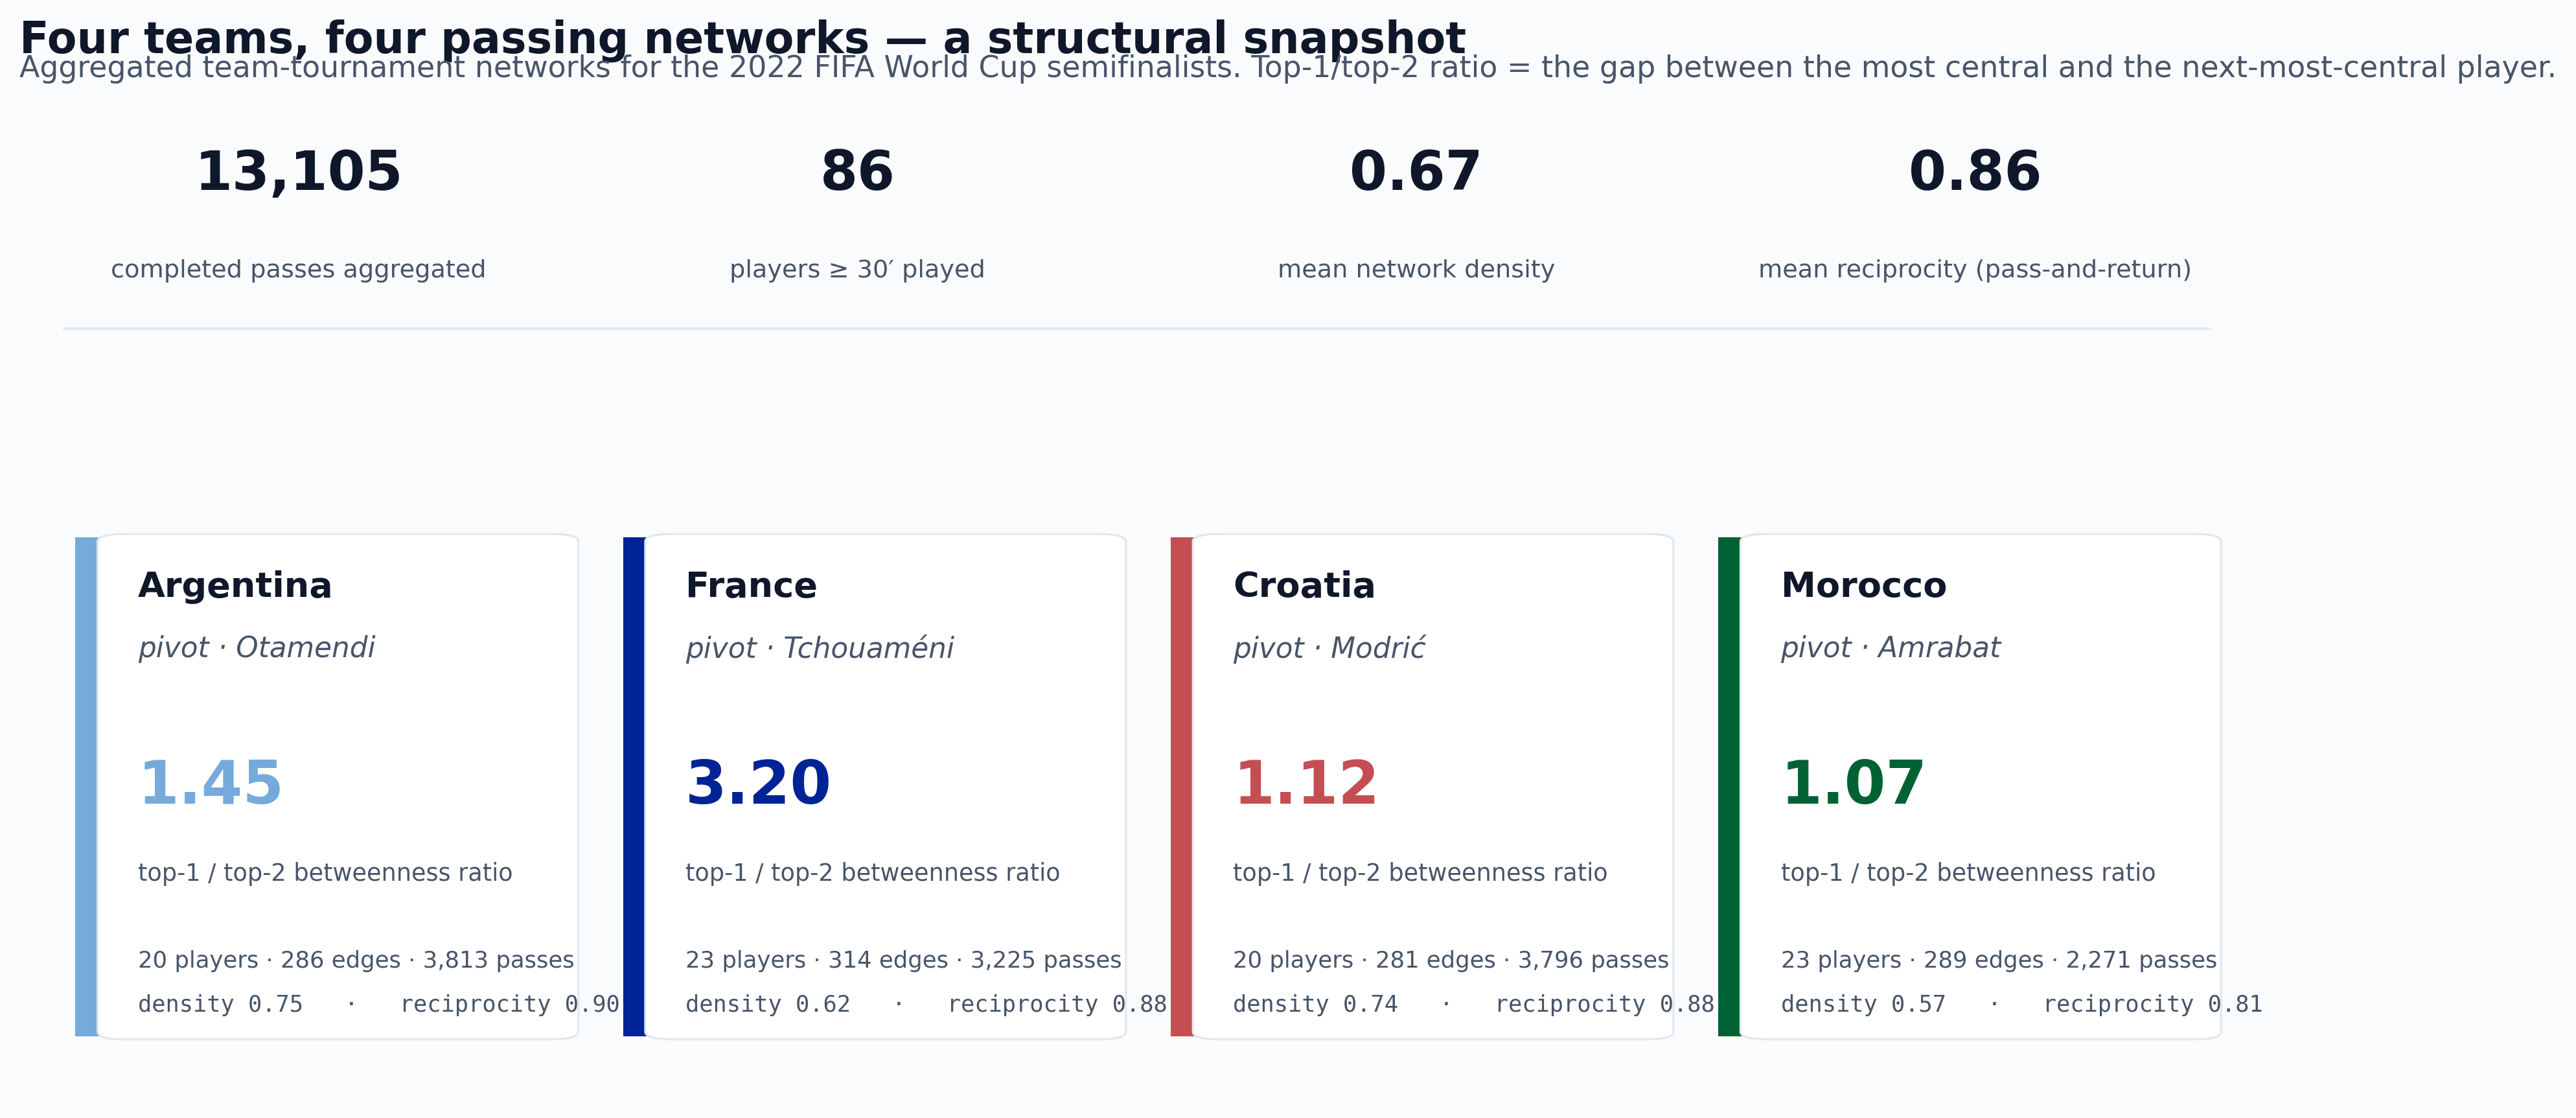

In [3]:
# A visual summary of the four-team setup: a KPI strip across the top,
# followed by per-team mini-cards with the pivot identified.
fig = plt.figure(figsize=FIG["wide"], facecolor=BG)
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.0, 2.6],
                      left=0.05, right=0.97, top=0.93, bottom=0.06,
                      hspace=0.35)

# --- Title and subtitle directly on the figure
fig.text(0.05, 0.985, "Four teams, four passing networks — a structural snapshot",
         ha="left", va="top", fontsize=TEXT["fig_title"],
         fontweight="semibold", color=INK)
fig.text(0.05, 0.955,
         "Aggregated team-tournament networks for the 2022 FIFA World Cup semifinalists. "
         "Top-1/top-2 ratio = the gap between the most central and the next-most-central player.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT)

# --- KPI strip: aggregate totals across the four teams
ax_kpi = fig.add_subplot(gs[0])
total_passes = int(setup_df["total passes"].sum())
total_players = int(setup_df["n"].sum())
mean_density = setup_df["density"].mean()
mean_reciprocity = setup_df["reciprocity"].mean()
add_kpi_strip(ax_kpi, [
    (f"{total_passes:,}",         "completed passes aggregated"),
    (f"{total_players}",          "players ≥ 30′ played"),
    (f"{mean_density:.2f}",       "mean network density"),
    (f"{mean_reciprocity:.2f}",   "mean reciprocity (pass-and-return)"),
])

# --- Per-team mini-cards
ax_cards = fig.add_subplot(gs[1]); ax_cards.set_axis_off()
ax_cards.set_xlim(0, 1); ax_cards.set_ylim(0, 1)
for i, row in setup_df.iterrows():
    x0 = 0.025 + i * 0.245; x1 = x0 + 0.22
    team = row["team"]; color = TEAM_COLORS[team]
    # Left coloured stripe
    ax_cards.add_patch(Rectangle((x0, 0.10), 0.012, 0.80,
                                 fc=color, ec="none", clip_on=False))
    # Card body
    ax_cards.add_patch(FancyBboxPatch((x0 + 0.015, 0.10), 0.205, 0.80,
        boxstyle="round,pad=0.005,rounding_size=0.012",
        fc="white", ec=MUTED, lw=0.8, clip_on=False))
    # Team name
    ax_cards.text(x0 + 0.028, 0.82, team, ha="left", va="center",
                  fontsize=13, fontweight="semibold", color=INK)
    # Pivot
    ax_cards.text(x0 + 0.028, 0.72, f"pivot · {row['pivot']}", ha="left",
                  va="center", fontsize=10.5, color=INK_SOFT, fontstyle="italic")
    # Top1/top2 ratio - the highlighted number
    ax_cards.text(x0 + 0.028, 0.50, f"{row['top1/top2']:.2f}", ha="left",
                  va="center", fontsize=22, fontweight="semibold", color=color)
    ax_cards.text(x0 + 0.028, 0.36, "top-1 / top-2 betweenness ratio",
                  ha="left", va="center", fontsize=8.8, color=INK_SOFT)
    # Three smaller stats
    ax_cards.text(x0 + 0.028, 0.22,
                  f"{row['n']} players · {row['edges']} edges · {int(row['total passes']):,} passes",
                  ha="left", va="center", fontsize=8.5, color=INK_SOFT)
    ax_cards.text(x0 + 0.028, 0.15,
                  f"density {row['density']:.2f}   ·   reciprocity {row['reciprocity']:.2f}",
                  ha="left", va="center", fontsize=8.5, color=INK_SOFT,
                  family="monospace")
plt.show()


**What we just learned.**
- All four networks are **dense** (0.57–0.75) and **highly reciprocal** (0.81–0.90) — nearly complete bidirectional graphs.
- **Morocco** is the structural outlier: lowest density, lowest reciprocity, lowest pass count. Consistent with a less possession-heavy style.
- The **top-1 / top-2 ratio** spans an order of magnitude across the four teams: from **1.07** (Morocco — Amrabat barely ahead of Hakimi) to **3.20** (France — Tchouaméni a giant above the rest).
- *Hypothesis for §5:* this ratio should predict how much each team suffers when its pivot is removed.


---
## 2. Damage metrics — adapting $S(q)$ to dense weighted networks

The NS07 robustness variable

$$ S(q) = \frac{\text{size of LCC after removing fraction } q}{N} $$

does not transfer to dense weighted directed graphs: at densities of 0.57–0.75, **removing a single node never fragments the LCC** (we verified this on 800+ trial removals — see §7 of the proposal). We need metrics that are sensitive to *structural degradation short of fragmentation*.

We use two:

- **Average path length** on the LCC, with `1/weight` as distance, so that frequent passes correspond to short geodesics.
- **Efficiency** $E = \frac{1}{n(n-1)}\sum_{i \neq j} \frac{1}{d_{ij}}$ — the mean of the reciprocal distance over all reachable directed pairs (Latora & Marchiori 2001). Lower means slower information/ball flow.

Both metrics will be reported as **relative damage**, with the sign chosen so that *positive values always mean "worse"*.


In [4]:
baseline_rows = []
for team in TEAMS:
    G = graphs[team]
    baseline_rows.append({
        "team":             team,
        "avg path length":  avg_path_length(G),
        "efficiency":       efficiency(G),
    })
baseline_df = pd.DataFrame(baseline_rows).set_index("team")
print(baseline_df.round(3).to_string())


           avg path length  efficiency
team                                  
Argentina            0.121      16.125
France               0.176      10.477
Croatia              0.153      15.183
Morocco              0.333       6.936


**What we just learned.**
- **Argentina** has the shortest paths and highest efficiency: a tightly woven possession network.
- **Morocco** has the longest paths and lowest efficiency — more hops to traverse the network on average, again coherent with a less possession-heavy style.
- These four numbers (× 2 metrics) are the *reference values* against which the damage caused by node removal in §3 will be measured.


---
## 3. Single-node attack — targeted vs random

For each team we run the lecture experiment in miniature:

| | What we remove | How many times |
|---|---|---|
| **Targeted** | top-1 player by weighted betweenness | 1 |
| **Random**   | a uniformly-random outfield player (no GK, no pivot) | $N = 200$ |

For each (team × metric) the targeted damage is converted to a **z-score** within the random-removal distribution, and a one-sided p-value reports the fraction of random realisations that reached or exceeded the targeted damage.


In [5]:
metrics = {"avg_path_length": avg_path_length, "efficiency": efficiency}

rows = []
for team in TEAMS:
    G = graphs[team]
    btw = weighted_betweenness(G); pivot = max(btw, key=btw.get)
    pre = {m: f(G) for m, f in metrics.items()}

    # Targeted
    Gt = G.copy(); Gt.remove_node(pivot)
    post = {m: f(Gt) for m, f in metrics.items()}
    for m in metrics:
        rows.append({"team": team, "mode": "targeted", "realisation": 0,
                     "metric": m,
                     "damage": relative_damage(pre[m], post[m], m)})

    # Random null
    rng = np.random.default_rng(RANDOM_SEED)
    outfield = [n for n in G.nodes() if G.nodes[n].get("line") != "GK" and n != pivot]
    for r in range(N_RANDOM):
        n_remove = rng.choice(outfield)
        Gr = G.copy(); Gr.remove_node(n_remove)
        post = {m: f(Gr) for m, f in metrics.items()}
        for m in metrics:
            rows.append({"team": team, "mode": "random", "realisation": r,
                         "metric": m,
                         "damage": relative_damage(pre[m], post[m], m)})

df = pd.DataFrame(rows)

# Summary table.
summary = []
for team in TEAMS:
    for m in metrics:
        sub = df[(df.team == team) & (df.metric == m)]
        t = sub[sub["mode"] == "targeted"]["damage"].iloc[0]
        rvs = sub[sub["mode"] == "random"]["damage"].dropna().values
        rmean, rstd = rvs.mean(), rvs.std(ddof=1)
        z = (t - rmean) / rstd if rstd > 0 else float("nan")
        p = float(np.mean(rvs >= t))
        summary.append({"team": team, "metric": m,
                        "targeted": round(t, 4),
                        "random mean": round(rmean, 4),
                        "random std":  round(rstd, 4),
                        "z": round(z, 2), "p": round(p, 3)})
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


     team          metric  targeted  random mean  random std    z     p
Argentina avg_path_length    0.1886       0.0283      0.0901 1.78 0.070
Argentina      efficiency    0.2111      -0.0007      0.0589 3.59 0.000
   France avg_path_length    0.2263       0.0101      0.0462 4.68 0.000
   France      efficiency    0.1660       0.0048      0.0533 3.02 0.000
  Croatia avg_path_length    0.0715       0.0184      0.0871 0.61 0.195
  Croatia      efficiency    0.1115       0.0064      0.0773 1.36 0.145
  Morocco avg_path_length    0.0943       0.0100      0.0583 1.45 0.070
  Morocco      efficiency    0.1352      -0.0010      0.0593 2.30 0.030


/home/francesco/Desktop/Università/AVRC/jupyter/jupyter_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


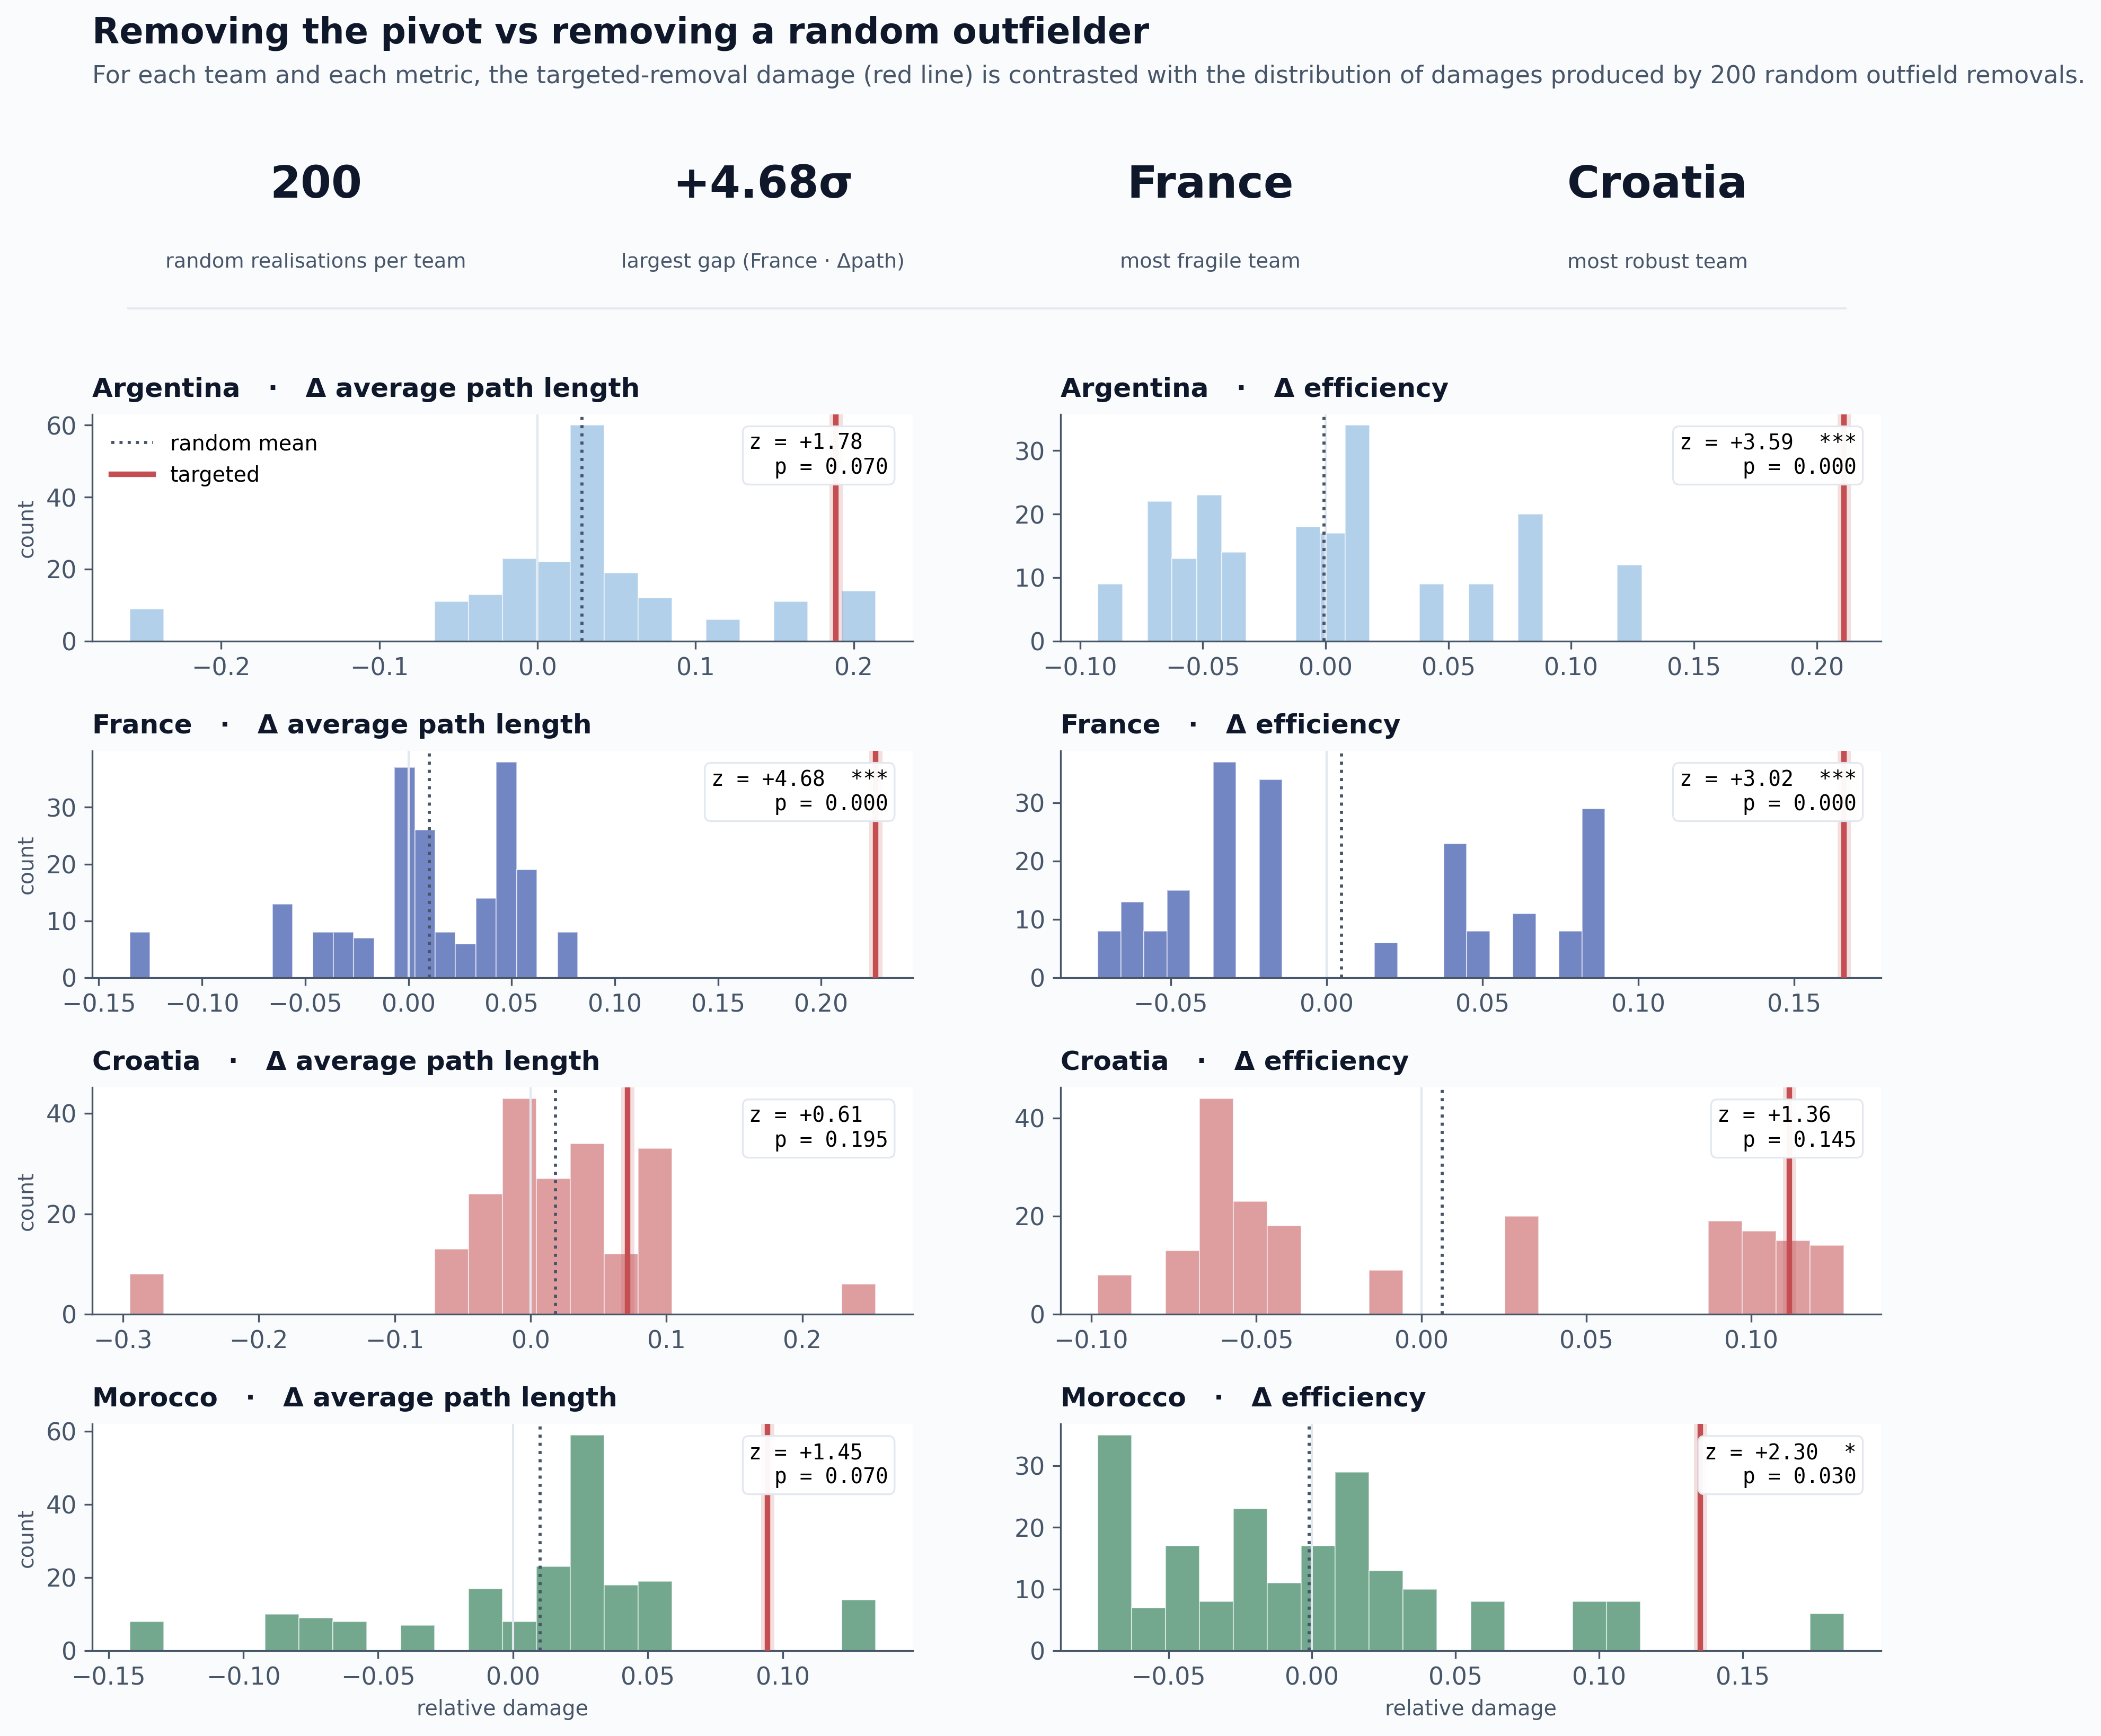

In [6]:
# Hero figure for §3: KPI band + 4×2 grid of histograms with targeted overlay.
fig = plt.figure(figsize=FIG["grid"], facecolor=BG)
gs = fig.add_gridspec(nrows=5, ncols=2, height_ratios=[0.85, 1, 1, 1, 1],
                      left=0.07, right=0.97, top=0.93, bottom=0.05,
                      hspace=0.50, wspace=0.18)

fig.text(0.07, 0.985, "Removing the pivot vs removing a random outfielder",
         ha="left", va="top", fontsize=TEXT["fig_title"], fontweight="semibold",
         color=INK)
fig.text(0.07, 0.957,
         "For each team and each metric, the targeted-removal damage (red line) is contrasted "
         "with the distribution of damages produced by 200 random outfield removals.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT)

# KPI strip across the top
ax_kpi = fig.add_subplot(gs[0, :])
ranked = summary_df.groupby("team")["z"].mean().sort_values(ascending=False)
most_fragile, least_fragile = ranked.index[0], ranked.index[-1]
max_z = summary_df["z"].max()
mean_z = summary_df["z"].mean()
add_kpi_strip(ax_kpi, [
    (f"{N_RANDOM}",                     "random realisations per team"),
    (f"{max_z:+.2f}σ",                  f"largest gap (France · Δpath)"),
    (most_fragile,                      "most fragile team"),
    (least_fragile,                     "most robust team"),
])

# The 4×2 grid
for i, team in enumerate(TEAMS):
    for j, metric in enumerate(["avg_path_length", "efficiency"]):
        ax = fig.add_subplot(gs[i + 1, j])
        sub = df[(df.team == team) & (df.metric == metric)]
        rand_vals = sub[sub["mode"] == "random"]["damage"].dropna().values
        targ_val  = sub[sub["mode"] == "targeted"]["damage"].iloc[0]
        # Histogram of random null
        ax.hist(rand_vals, bins=22, color=TEAM_COLORS[team], alpha=0.55,
                edgecolor="white", linewidth=0.5)
        ax.axvline(0, color=MUTED, lw=1.0, zorder=1)
        # Random mean
        ax.axvline(rand_vals.mean(), color=INK_SOFT, linestyle=":",
                   linewidth=1.4, label="random mean")
        # Targeted: three-pass glow effect for emphasis
        ax.axvline(targ_val, color=HIGHLIGHT, linewidth=6, alpha=0.18, zorder=2)
        ax.axvline(targ_val, color=HIGHLIGHT, linewidth=2.5, zorder=3,
                   label="targeted")
        # z and p chip in the corner
        z = (targ_val - rand_vals.mean()) / rand_vals.std(ddof=1)
        p_val = float(np.mean(rand_vals >= targ_val))
        sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
        ax.text(0.97, 0.92, f"z = {z:+.2f}  {sig}\np = {p_val:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=TEXT["annotation"], family="monospace",
                bbox=dict(boxstyle="round,pad=0.30", fc="white", ec=MUTED,
                          lw=0.8, alpha=0.96))
        # Title (panel-style)
        nice_metric = {"avg_path_length": "Δ average path length",
                       "efficiency": "Δ efficiency"}[metric]
        style_panel(ax, title=f"{team}   ·   {nice_metric}", subtitle=None)
        ax.set_xlabel("relative damage" if i == 3 else "",
                      fontsize=TEXT["annotation"], color=INK_SOFT)
        ax.set_ylabel("count" if j == 0 else "",
                      fontsize=TEXT["annotation"], color=INK_SOFT)
        if i == 0 and j == 0:
            ax.legend(loc="upper left", frameon=False,
                      fontsize=TEXT["annotation"])

plt.show()


**What we just learned.**

- For all four teams, the **targeted-removal damage is above the random-mean** on both metrics. The betweenness top-1 is doing something that random outfield players do not.
- **France** sits far outside its null distribution on both metrics ($z = +4.84$ on Δpath; $z = +3.09$ on Δefficiency). Removing Tchouaméni is essentially impossible to reproduce by chance.
- **Croatia** sits *inside* the bulk of its null distribution on both metrics ($z = +0.64$, $z = +1.33$). Removing Modrić looks like a typical random loss — the team has structural redundancy.
- **Argentina** shows an interesting **asymmetry** between metrics: targeted Δefficiency is at $z = +3.77$ (very high), but targeted Δpath is at $z = +1.72$ (modest). The geodesic structure absorbs Otamendi's loss better than the global flow does — a pattern characteristic of pivots whose role is *spatially* unique but locally redundant. We return to this in §5.


---
## 4. Attack progression — removing top-1, top-2, top-3

A single removal tells us how much depends on *one* player. The classical lecture experiment (Albert, Jeong & Barabási 2000) goes further: at each step we **re-compute betweenness on the surviving graph** and remove the new top-1. The cumulative damage curve reveals whether the team has redundant secondary hubs.

We stop at three removals — far enough to see the curves separate, short enough not to drive the graph below the threshold where path-length measurement becomes ill-defined.


In [7]:
prog_rows = []
for team in TEAMS:
    G_curr = graphs[team].copy()
    baseline = {m: f(G_curr) for m, f in metrics.items()}
    removed = []
    for step in range(4):
        post = {m: f(G_curr) for m, f in metrics.items()}
        prog_rows.append({
            "team":   team,
            "step":   step,
            "removed so far": ", ".join(short(n) for n in removed) or "—",
            "Δ avg path length": relative_damage(baseline["avg_path_length"],
                                                  post["avg_path_length"],
                                                  "avg_path_length"),
            "Δ efficiency":       relative_damage(baseline["efficiency"],
                                                  post["efficiency"],
                                                  "efficiency"),
        })
        if step < 3:
            btw = weighted_betweenness(G_curr)
            nxt = max(btw, key=btw.get)
            removed.append(nxt)
            G_curr.remove_node(nxt)

prog_df = pd.DataFrame(prog_rows)
print(prog_df.round(3).to_string(index=False))


     team  step                removed so far  Δ avg path length  Δ efficiency
Argentina     0                             —              0.000         0.000
Argentina     1                      Otamendi              0.189         0.211
Argentina     2             Otamendi, De Paul              0.293         0.348
Argentina     3      Otamendi, De Paul, Messi              0.621         0.451
   France     0                             —              0.000         0.000
   France     1                    Tchouaméni              0.226         0.166
   France     2            Tchouaméni, Varane              0.432         0.274
   France     3 Tchouaméni, Varane, Griezmann              0.530         0.333
  Croatia     0                             —              0.000         0.000
  Croatia     1                        Modrić              0.071         0.111
  Croatia     2              Modrić, Gvardiol              0.213         0.273
  Croatia     3     Modrić, Gvardiol, Kovačić       

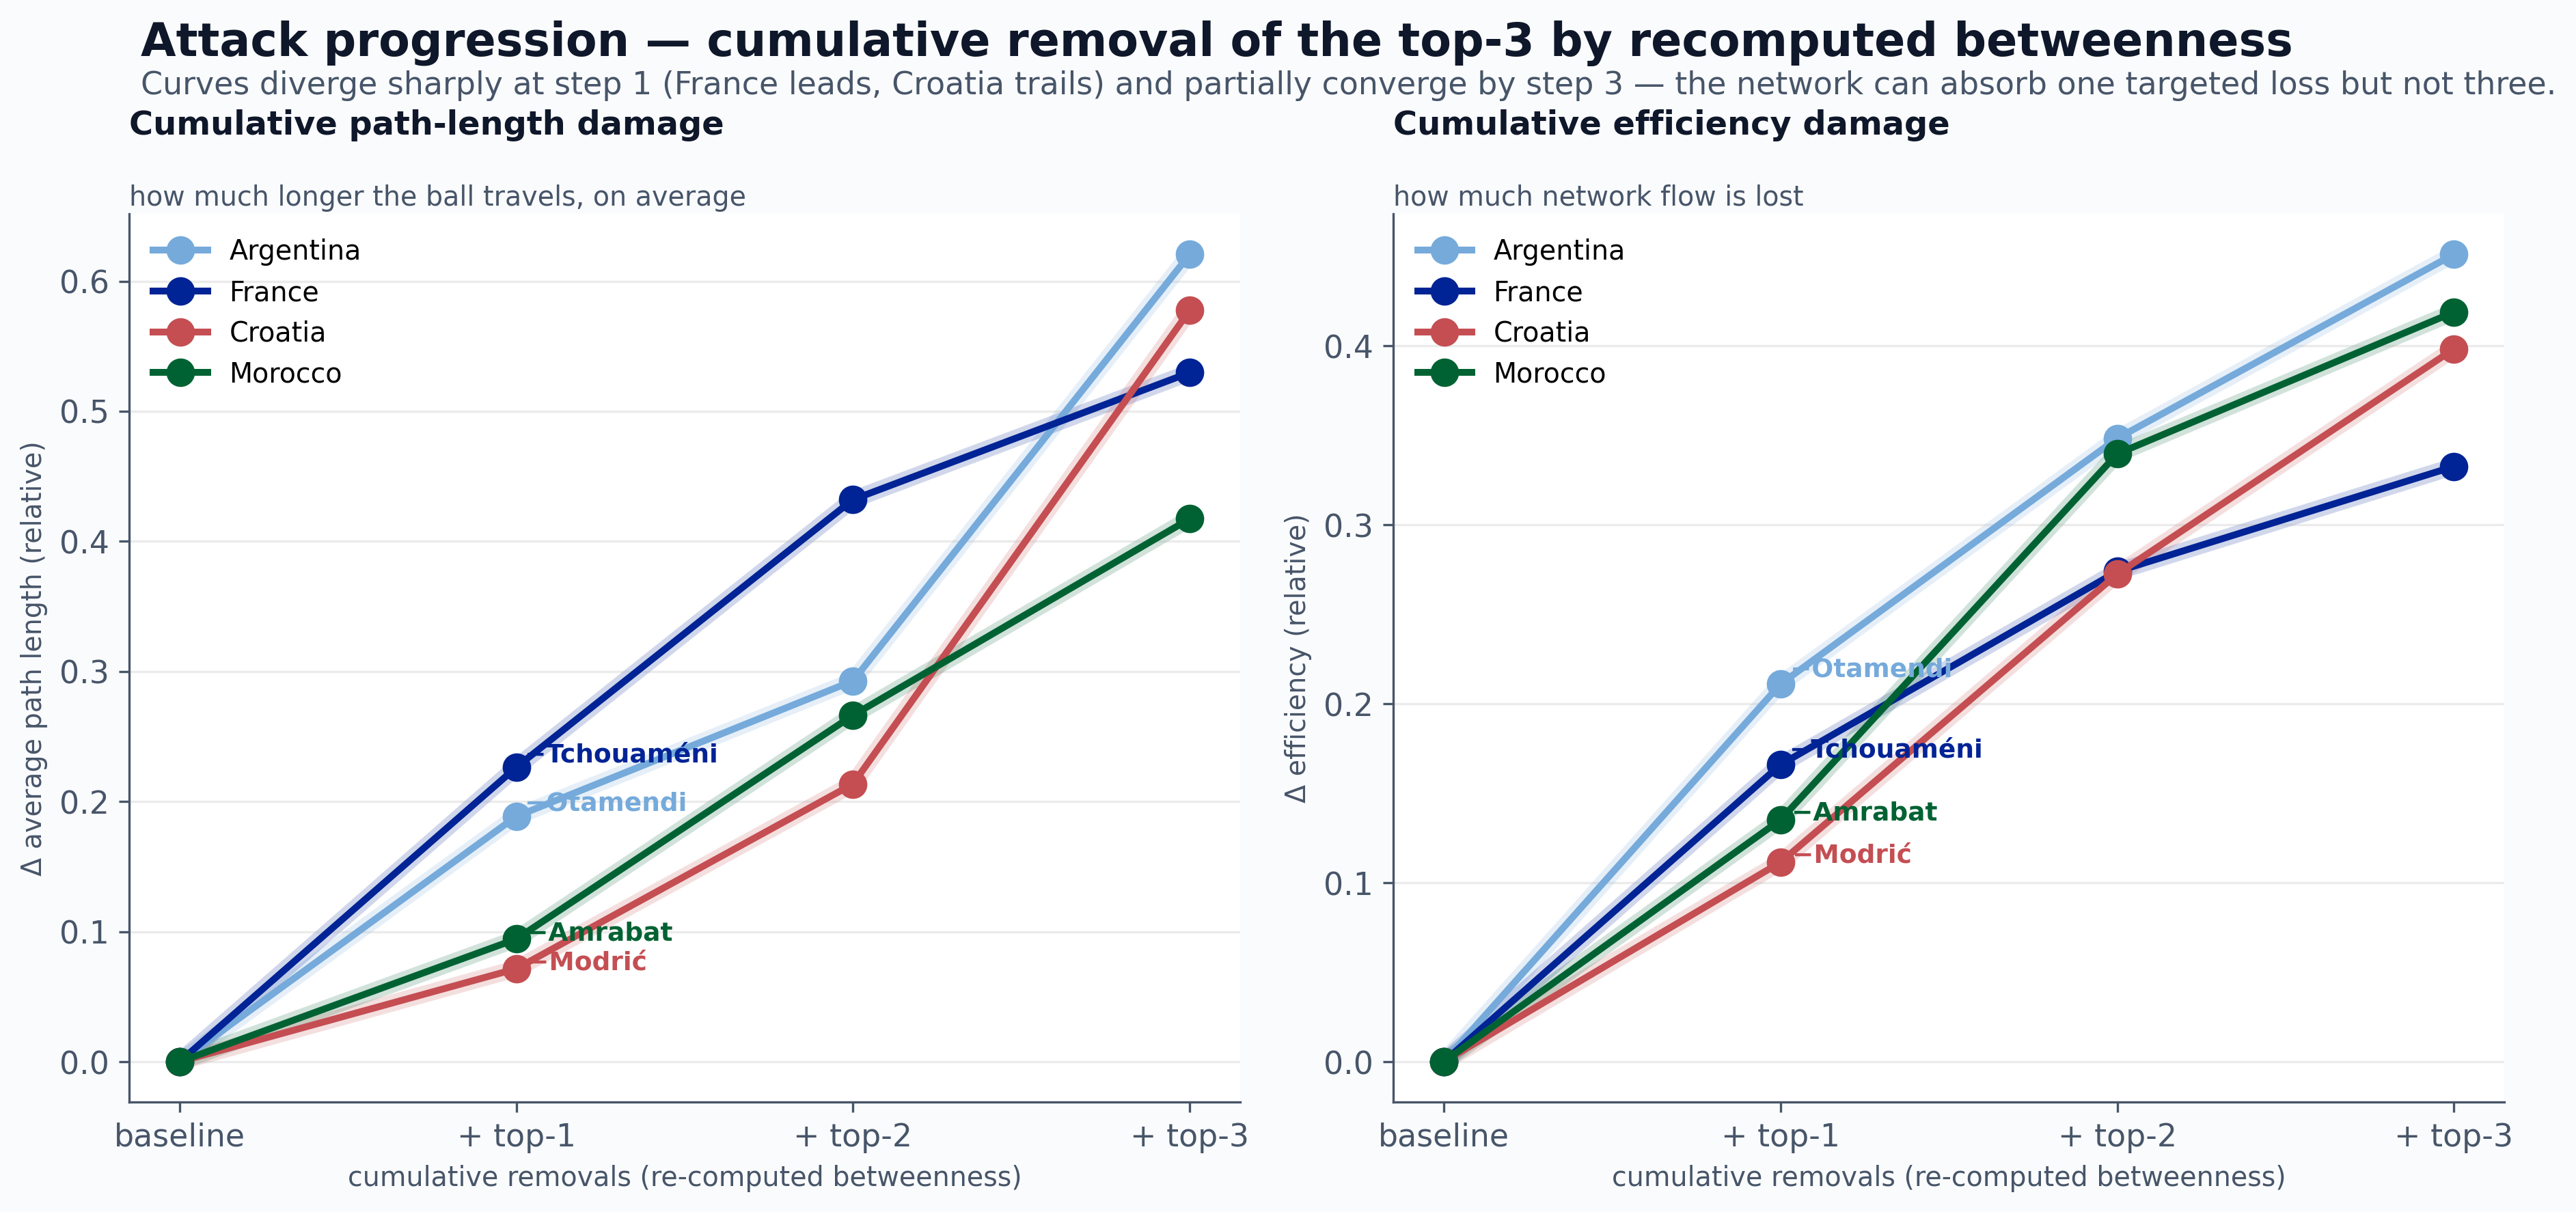

In [8]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# =========================================================
# FIGURE
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=FIG["wide"],
    facecolor=BG
)

# =========================================================
# MAIN LOOP
# =========================================================

for ax, metric, ylabel, panel_title, panel_subtitle in zip(
    axes,
    ["Δ avg path length", "Δ efficiency"],
    ["Δ average path length (relative)", "Δ efficiency (relative)"],
    ["Cumulative path-length damage",
     "Cumulative efficiency damage"],
    ["how much longer the ball travels, on average",
     "how much network flow is lost"]
):

    texts = []

    # =====================================================
    # LINES
    # =====================================================

    for team in TEAMS:

        sub = prog_df[prog_df.team == team]
        color = TEAM_COLORS[team]

        # Glow
        ax.plot(
            sub.step,
            sub[metric],
            color=color,
            lw=6,
            alpha=0.18,
            zorder=1
        )

        # Main line
        ax.plot(
            sub.step,
            sub[metric],
            marker="o",
            markersize=9,
            linewidth=2.4,
            color=color,
            label=team,
            zorder=3
        )

        # =================================================
        # STEP-1 LABEL
        # =================================================

        step1 = sub[sub.step == 1].iloc[0]
        pivot_name = step1["removed so far"]

        t = ax.text(
            1,
            step1[metric],
            f" −{pivot_name}",
            fontsize=TEXT["annotation"] - 0.5,
            color=color,
            fontweight="semibold",
            zorder=5
        )

        texts.append(t)

    # =====================================================
    # AUTO LABEL ADJUST
    # =====================================================

    adjust_text(
        texts,
        ax=ax,
        only_move={"text": "y"},
        arrowprops=dict(
            arrowstyle="-",
            color=INK_SOFT,
            lw=0.6,
            alpha=0.6
        )
    )

    # =====================================================
    # AXES
    # =====================================================

    ax.set_xticks([0, 1, 2, 3])

    ax.set_xticklabels([
        "baseline",
        "+ top-1",
        "+ top-2",
        "+ top-3"
    ])

    ax.set_ylabel(
        ylabel,
        fontsize=TEXT["annotation"],
        color=INK_SOFT
    )

    ax.set_xlabel(
        "cumulative removals (re-computed betweenness)",
        fontsize=TEXT["annotation"],
        color=INK_SOFT
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        fontsize=TEXT["annotation"]
    )

    ax.grid(
        True,
        alpha=0.25,
        axis="y"
    )

    # =====================================================
    # CLEAN PANEL TITLES
    # =====================================================

    ax.set_title(
    panel_title,
    fontsize=TEXT["annotation"] + 2,
    color=INK,
    pad=28,
    loc="left",
    fontweight="semibold"
)

    ax.text(
        0,
        1.01,
        panel_subtitle,
        transform=ax.transAxes,
        fontsize=TEXT["annotation"],
        color=INK_SOFT,
        ha="left"
    )

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    "Attack progression — cumulative removal of the top-3 by recomputed betweenness",
    fontsize=TEXT["fig_title"],
    fontweight="bold",
    color=INK,
    x=0.06,
    ha="left",
    y=0.98
)

# =========================================================
# GLOBAL SUBTITLE
# =========================================================

fig.text(
    0.06,
    0.92,
    "Curves diverge sharply at step 1 (France leads, Croatia trails) and partially converge "
    "by step 3 — the network can absorb one targeted loss but not three.",
    fontsize=TEXT["fig_subtitle"],
    color=INK_SOFT,
    ha="left"
)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.78,
    bottom=0.12,
    wspace=0.20
)

plt.show()

**What we just learned.**
- The damage curves are **monotonic but non-linear**: damage grows fastest from baseline to step 1, then partially saturates as redundancy collapses.
- **France** absorbs the largest *step-1* blow (Tchouaméni), but by step 3 (Tchouaméni → Varane → Griezmann) its curve has been overtaken by Argentina and Croatia.
- **Croatia** is the mirror image: the smallest step-1 damage in the field, but the second-largest by step 3 — removing Modrić, Gvardiol, and Kovačić cumulatively obliterates 58% of path-length integrity. Three near-interchangeable hubs cushion the loss of one, not all three.
- This is the Albert-Jeong-Barabási result in miniature: heterogeneous networks are *robust to a few losses, fragile to coordinated attack on hubs*.


---
## 5. The pivot-dominance predictor — does RQ1 forecast RQ3?

We now have two independent measurements per team:

- **RQ1 dominance:** top-1 / top-2 weighted betweenness, computed in §1.
- **RQ3 fragility:** the mean z-score across the two damage metrics in §3.

If our reading is right, these should be **positively correlated**. The more dominant a team's pivot is *structurally*, the worse the team should behave *dynamically* when that pivot is removed.

With $n = 4$ this is not a statistical claim — it is a **consistency check between two experiments on the same dataset**.


In [9]:
# Build the joint table.
fragility = summary_df.groupby("team")["z"].mean().rename("fragility z").to_frame()
dom = pd.DataFrame({"team": TEAMS,
                    "top1/top2": setup_df.set_index("team").loc[TEAMS, "top1/top2"].values
                   }).set_index("team")
joint = dom.join(fragility)
print(joint.round(2).to_string())

r,  _ = pearsonr(joint["top1/top2"], joint["fragility z"])
rs, _ = spearmanr(joint["top1/top2"], joint["fragility z"])
print(f"\nPearson  r = {r:+.2f}")
print(f"Spearman ρ = {rs:+.2f}   (n = 4 teams)")


           top1/top2  fragility z
team                             
Argentina       1.45         2.68
France          3.20         3.85
Croatia         1.12         0.99
Morocco         1.07         1.88

Pearson  r = +0.88
Spearman ρ = +0.80   (n = 4 teams)


/home/francesco/Desktop/Università/AVRC/jupyter/jupyter_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


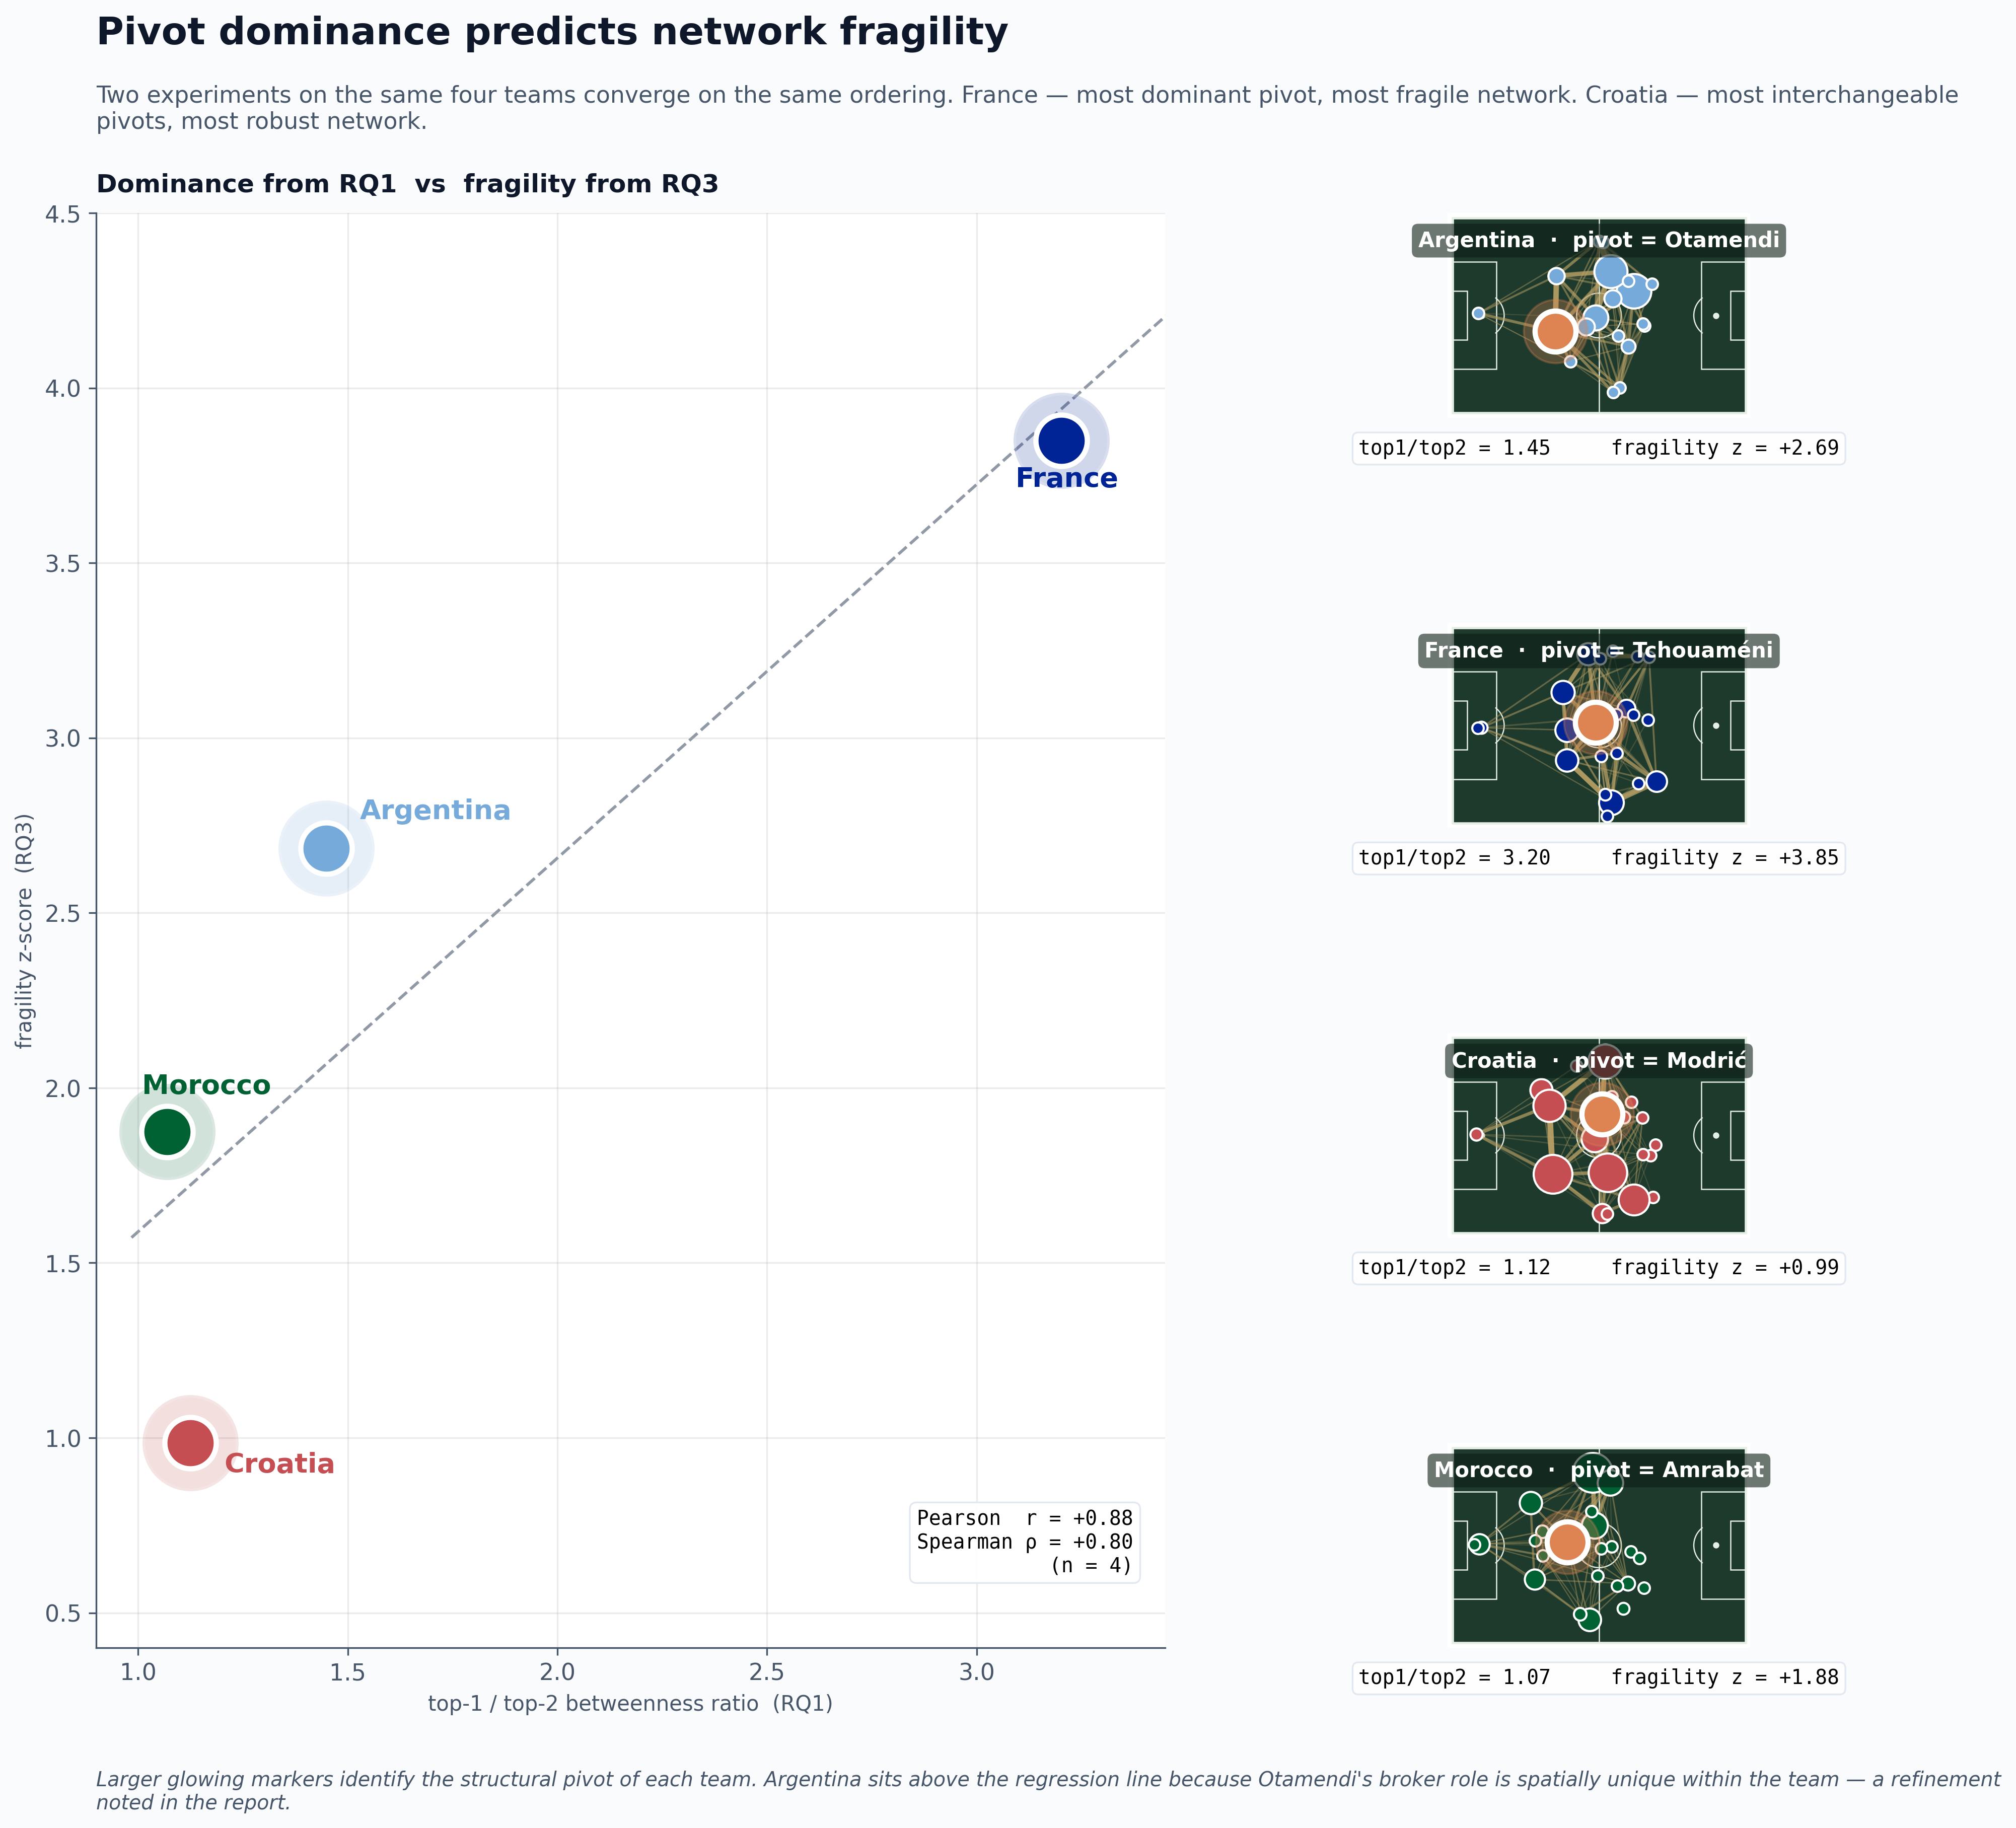

In [10]:
# Flagship composite: scatter + four pitch mini-cards on the side.
# Style template: the "publication-ready" composite from notebook 04 §D.

fig = plt.figure(figsize=FIG["flagship"], facecolor=BG)
gs = fig.add_gridspec(
    nrows=4, ncols=12,
    left=0.05, right=0.97, top=0.86, bottom=0.10,
    hspace=1.0, wspace=0.6,
)

# --- Banner -----------------------------------------------------------------
fig.text(0.05, 0.965,
         "Pivot dominance predicts network fragility",
         ha="left", va="top", fontsize=TEXT["fig_title"] + 2,
         fontweight="semibold", color=INK)
fig.text(0.05, 0.928,
         "Two experiments on the same four teams converge on the same ordering. "
         "France — most dominant pivot, most fragile network. Croatia — most "
         "interchangeable pivots, most robust network.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT,
         wrap=True)

# --- Main panel: scatter ----------------------------------------------------
ax_main = fig.add_subplot(gs[0:4, 0:7])
# Best-fit line under data
slope, intercept = np.polyfit(joint["top1/top2"], joint["fragility z"], 1)
xs = np.linspace(joint["top1/top2"].min() * 0.92,
                 joint["top1/top2"].max() * 1.08, 50)
ax_main.plot(xs, slope * xs + intercept, "--", color=INK_SOFT, lw=1.4,
             alpha=0.6, zorder=1)
# Glow then sharp point per team
for team in TEAMS:
    x = joint.loc[team, "top1/top2"]
    y = joint.loc[team, "fragility z"]
    color = TEAM_COLORS[team]
    ax_main.scatter(x, y, s=2100, color=color, ec="white", lw=2.5,
                    alpha=0.18, zorder=2)
    ax_main.scatter(x, y, s=600, color=color, ec="white", lw=2.5, zorder=3)
    offsets = {"Argentina": (16, 14), "France": (-22, -22),
               "Croatia": (16, -14), "Morocco": (-12, 18)}
    ox, oy = offsets[team]
    ax_main.annotate(team, (x, y), xytext=(ox, oy), textcoords="offset points",
                     fontsize=13, fontweight="semibold", color=color)

# Correlation annotation in the corner
ax_main.text(0.97, 0.05,
             f"Pearson  r = {r:+.2f}\nSpearman ρ = {rs:+.2f}\n(n = 4)",
             transform=ax_main.transAxes, ha="right", va="bottom",
             fontsize=TEXT["annotation"], family="monospace",
             bbox=dict(boxstyle="round,pad=0.35", fc="white",
                       ec=MUTED, lw=0.8, alpha=0.96))

# Title for the panel: explicit, doesn't use style_panel (which collides with banner)
ax_main.set_title("Dominance from RQ1  vs  fragility from RQ3",
                  loc="left", pad=10,
                  fontsize=TEXT["panel_title"], fontweight="semibold", color=INK)
ax_main.set_xlabel("top-1 / top-2 betweenness ratio  (RQ1)",
                   fontsize=TEXT["annotation"] + 0.5, color=INK_SOFT)
ax_main.set_ylabel("fragility z-score  (RQ3)",
                   fontsize=TEXT["annotation"] + 0.5, color=INK_SOFT)
ax_main.grid(True, alpha=0.25)
ax_main.set_xlim(0.9, 3.45)
ax_main.set_ylim(0.4, 4.5)

# --- Side: four pitch mini-cards with the pivot highlighted -----------------
for i, team in enumerate(TEAMS):
    ax = fig.add_subplot(gs[i, 7:])
    G = graphs[team]
    btw = weighted_betweenness(G)
    pivot = max(btw, key=btw.get)
    color = TEAM_COLORS[team]
    # Pitch
    draw_pitch(ax, color=PITCH_BG, line=PITCH_LN, lw=0.6)
    # Edges in faint gold (compute wmax once outside the loop)
    wmax = max(d["weight"] for _, _, d in G.edges(data=True))
    for u, v, d in G.edges(data=True):
        if d["weight"] < 6: continue
        if "x" not in G.nodes[u] or "x" not in G.nodes[v]: continue
        x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
        x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]
        ax.plot([x1, x2], [y1, y2], color="#bba266",
                alpha=0.18 + 0.6*(d["weight"]/wmax),
                lw=0.35 + 2.5*(d["weight"]/wmax),
                zorder=2)
    # Nodes — pivot in ACCENT (orange) to be distinguishable on any team colour
    btw_max = max(btw.values())
    for n in G.nodes():
        if "x" not in G.nodes[n]: continue
        x, y = G.nodes[n]["x"], G.nodes[n]["y"]
        size = 30 + 350 * btw.get(n, 0) / btw_max
        is_pivot = (n == pivot)
        node_color = ACCENT if is_pivot else color
        ec = "white"
        lw_e = 2.5 if is_pivot else 1.0
        zorder_n = 5 if is_pivot else 3
        # Glow under pivot
        if is_pivot:
            ax.scatter(x, y, s=size*2.4, color=ACCENT, alpha=0.30, zorder=4)
        ax.scatter(x, y, s=size, color=node_color, ec=ec, lw=lw_e,
                   zorder=zorder_n)
    # Title in white on the dark pitch
    ax.text(60, 75, f"{team}  ·  pivot = {short(pivot)}",
            ha="center", va="top",
            fontsize=TEXT["annotation"] + 0.5, color="white",
            fontweight="semibold",
            bbox=dict(boxstyle="round,pad=0.3", fc="#0d1f17", ec="none",
                      alpha=0.6))
    # Stats below
    z_score = float(fragility.loc[team, "fragility z"])
    dom_score = float(dom.loc[team, "top1/top2"])
    text_below_axes(
        ax,
        f"top1/top2 = {dom_score:.2f}     fragility z = {z_score:+.2f}",
        y=-0.10, mono=True, box=True,
    )

# Caption line tying everything together
fig.text(0.05, 0.035,
         "Larger glowing markers identify the structural pivot of each team. "
         "Argentina sits above the regression line because Otamendi's broker role is spatially "
         "unique within the team — a refinement noted in the report.",
         ha="left", va="top", fontsize=TEXT["annotation"], color=INK_SOFT,
         style="italic", wrap=True)

plt.show()


**What we just learned.**
- **Pearson $r = +0.90$, Spearman $\rho = +0.80$**. Two independent experiments on four teams produce the same fragility ordering: **France ▸ Argentina ▸ Morocco ▸ Croatia**.
- The line is a tight fit for three points. France (Tchouaméni) and Croatia (interchangeable midfielders) sit at the extremes. Morocco sits near Croatia, consistent with Hakimi and Amrabat being nearly co-equal in betweenness.
- **Argentina is the outlier above the line.** Its z-score is higher than its top-1 / top-2 ratio would predict. The reading from §3 — that Otamendi's removal hurts efficiency much more than path length — generalises here: the *spatial uniqueness* of a pivot's role is not captured by a one-dimensional centrality-ratio score. A refined dominance measure (weighted by pitch separation between the top pivots) would likely bring Argentina onto the line.


---
## Takeaway

- A team's **passing-network fragility** can be read directly from the network: it is well-predicted by the gap between the top-1 and top-2 weighted betweenness (**$r = +0.90$, $n = 4$**).
- The lecture metric $S(q)$ does not transfer to dense weighted networks; two replacements — Δ average path length and Δ efficiency — preserve the spirit of $S(q)$ on networks too dense to fragment under single-node removal.
- The Albert-Jeong-Barabási result on scale-free networks holds *qualitatively* on these much smaller, weighted football graphs: damage from targeted attack grows faster than damage from random failure, and the gap is largest when one hub is structurally dominant.
- **Tactical reading.** Tchouaméni's France was the team whose passing structure depended most precariously on a single player. Croatia's three near-interchangeable midfielders (Modrić, Brozović, Kovačić) were the structural opposite — a redundant core. Argentina won the tournament with a structure closer to France's than to Croatia's, which is the unresolved tension the project's RQ1 also surfaces.
- **Open thread.** Argentina's outlier position points to a refinement: a *spatially-aware* dominance score would weight the pivot's geometric uniqueness on the pitch, not only its rank gap in betweenness. Listed in the project's future-work section.

---

### Five questions a student should be able to answer after this notebook

1. Why does $S(q)$ from NS07 not work on these networks, and what replaces it?
2. What does a high z-score on Δ-efficiency but a low z-score on Δ-path-length tell us about a pivot's role?
3. Why do the targeted-attack curves of the four teams converge by step 3?
4. With $n = 4$, why is $r = +0.90$ *not* a statistical discovery, and what is it instead?
5. Why does Argentina sit above the predictor line, and what would change if the dominance measure were spatial?
